In [25]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import sklearn.gaussian_process as gp
import os
from IPython.display import display, Math

sys.path.append('../nn_model')
sys.path.append('..')
sys.path.append('../data')

sys.path.append('../GP_regr')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
import SR_lib

import nn_model_lib as _lib

from nn_model_lib import *


def import_reload():
    importlib.reload(plot_settings)
    importlib.reload(SR_lib)


import_reload()

## Initial Setup

In [ ]:
RUN_ID = 'test1'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1.5e1)

REF_VALUES = SR_lib.get_ref_values()

UNITS, UNIT_CONV = SR_lib.get_units_dict()

SELECTION = "best"

if os.path.exists(f'saved_sr_models/{RUN_ID}'):
    raise ValueError(f'Run ID {RUN_ID} already exists. Please choose a different one.')


Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'false', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'false', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'false', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'false', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'false', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k unconstrained
ds/dt unconstrained  (dynamic sdotNet)
R1 unconstrained
C1 unconstrained
R0 unconstrained


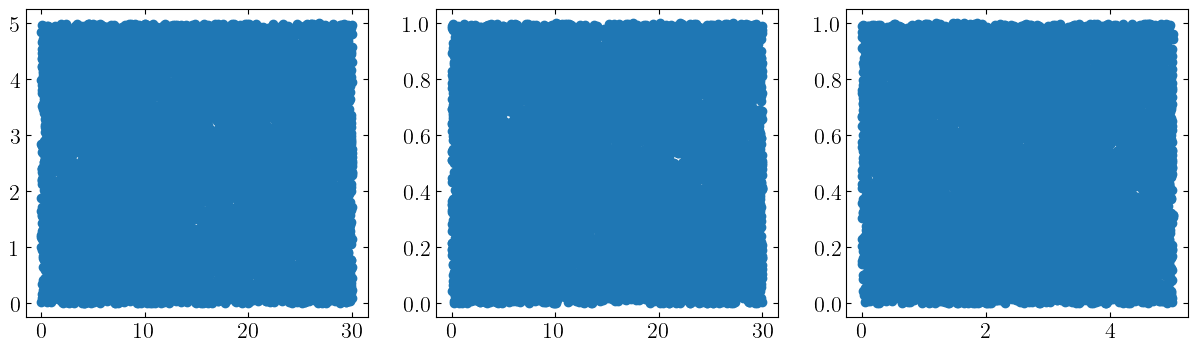

In [27]:
model_name = '0515_0840_b4_combo_softplus_combo_V-dynamic_F-dynamic_unconstr_700.40min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = pd.read_csv('SR_samples.csv', usecols=['u_par', 'C_rate', 'SOC'])

s_data = pd.read_csv('../data/polished_combo/combo_half.txt', delimiter=';')
#s_data = s_data[s_data['u_par', 'C', 'soc'].isin(df.values.tolist())]
f, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(df['u_par'],df['C_rate'], 'o')
ax[1].plot(df['u_par'],df['SOC'], 'o')
ax[2].plot(df['C_rate'],df['SOC'], 'o')

#display(df)
s_data_P = s_data[s_data['pulse'] == 1]

trajs = prepare_pulse_data(s_data_P)
s_df_p = data_param(BAT_MODEL, trajs, pulse = True)

s_data_CC = s_data[s_data['pulse'] == 0]
trajs = prepare_data(s_data_CC)
s_df_cc = data_param(BAT_MODEL, trajs, pulse = False)


In [28]:

s_df_tot = pd.concat([s_df_p, s_df_cc], ignore_index=True)
s_data = s_df_tot[['I', 'u_per', 'soc', 's', 'sdot']]
s_data['C'] = s_data['I'].copy() * 3600/Q0 
REF_VALUES['s'] = np.max(s_data['s'].values)
s_data['s'] = s_data['s'].copy() / REF_VALUES['s']
s_data['C'] = s_data['C'].copy() / REF_VALUES['C']
s_data['u_per'] = s_data['u_per'].copy() / REF_VALUES['d']

s_data['sdot'] = s_data['sdot'].copy() / REF_VALUES['sdot']

s_data.describe()

/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_30395/1282825791.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data['C'] = s_data['I'].copy() * 3600/Q0
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_30395/1282825791.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s_data['s'] = s_data['s'].copy() / REF_VALUES['s']
/var/folders/xl/schcbct544b8f32_b4484x5c0000gn/T/ipykernel_30395/1282825791.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a

,I,u_per,soc,s,sdot,C
count,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000,241518.000000
mean,6.959620,0.429038,0.544854,0.294561,0.869936,0.279603
std,6.807070,0.309418,0.257924,0.240674,1.009850,0.273474
min,0.000000,0.000000,0.024633,0.000000,0.003351,0.000000
25%,0.000000,0.176667,0.329973,0.093446,0.087223,0.000000
50%,4.480394,0.406667,0.548750,0.227796,0.599727,0.180000
75%,10.952074,0.686667,0.762836,0.459088,1.125820,0.440000
max,24.891078,0.990000,1.000000,1.000000,5.313158,1.000000


In [29]:
def R0_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R0')

def R1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='R1')

def C1_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='C1')

def k_nn(c_rate, u_per, soc):
    return element_predict(BAT_MODEL, c_rate, u_per, soc, element='k')

def sdot_nn(c_rate, u_per, soc, s):
    return sdot_predict(BAT_MODEL, c_rate, u_per, soc, s)


def sample_element(c_rate, u_per, soc):
    R0 = R0_nn(c_rate, u_per, soc)
    R1 = R1_nn(c_rate, u_per, soc)
    C1 = C1_nn(c_rate, u_per, soc)
    k = k_nn(c_rate, u_per, soc)
    return R0.item(), R1.item(), C1.item(), k.item()


def generate_data(data, ref_values=REF_VALUES):
    samples = np.zeros((len(data),4+3))
    for row in trange(len(data)):
        u_per,c_rate, soc = data[row]
        r0, r1,c1,k = sample_element(c_rate, u_per, soc)
        samples[row] = [r0 / ref_values['R0'], r1/ ref_values['R1'], c1/ ref_values['C1'], k / ref_values['k'], c_rate, u_per, soc]
    return samples


In [30]:
samples = generate_data(df.values)

100%|██████████| 10000/10000 [00:08<00:00, 1193.74it/s]


In [31]:
cols = VARIABLES + ['C', 'u_per', 'soc']
df_samples = pd.DataFrame(samples, columns=cols)
data = df_samples
data['u_per'] =  data['u_per'] / REF_VALUES['d']
data['C'] =  data['C'] / REF_VALUES['C']

data.describe() 

,R0,R1,C1,k,C,u_per,soc
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.823645,5.678430,9.447663,2.887359,0.499987,0.499977,0.499957
std,0.149276,10.257809,3.838857,0.377416,0.288700,0.288720,0.288703
min,0.400871,0.188216,0.123883,2.239312,0.000000,0.000000,0.000000
25%,0.744825,0.592013,10.566363,2.558353,0.249950,0.250008,0.250000
50%,0.809587,0.721194,11.240972,2.840583,0.500000,0.500017,0.500000
75%,0.877739,1.949865,11.378365,3.192075,0.750000,0.749958,0.750000
max,1.482466,28.958312,13.489980,3.777907,1.000000,0.999900,1.000000


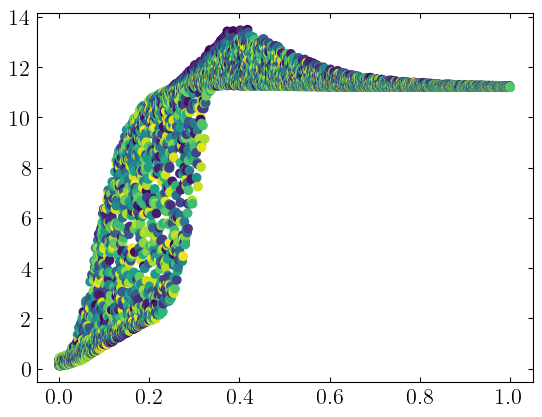

In [32]:
# plotting
arg_soc_sort = np.argsort(df_samples['soc'])
soc_sort = df_samples['soc'].values[arg_soc_sort]
R0_sort = df_samples['R0'].values[arg_soc_sort]
R1_sort = df_samples['R1'].values[arg_soc_sort]
C1_sort = df_samples['C1'].values[arg_soc_sort]
k_sort = df_samples['k'].values[arg_soc_sort]

#plt.plot(soc_sort, R0_sort, '-', label='R0')
#plt.plot(soc_sort, R1_sort, '-', label='R1')
plt.scatter(soc_sort, C1_sort, c = df_samples['u_per'].values[arg_soc_sort], label='C1')
#plt.plot(soc_sort, k_sort, '-', label='k')

# Importing data

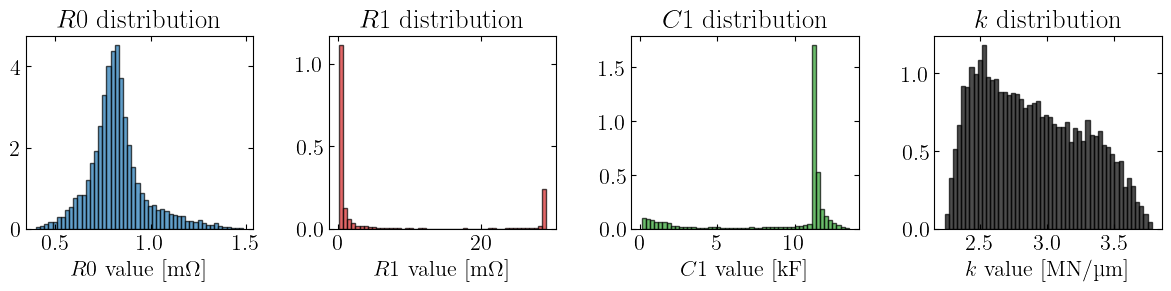

In [33]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

# f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

# for i, var in enumerate(VARIABLES):
#     ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
#     ax[i].set_title(f'${var}$ distribution')
#     ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
# plt.tight_layout()
# plt.show()

In [34]:
def get_XY(d_frame, s_frame = None):

    if s_frame is not None:
        for i in range(1,10):
            inds = np.arange(0,len(s_frame)) % i == 0
            if inds.sum() < 1e4:
                break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values 
    Y_R1 = d_frame['R1'].values 
    Y_C1 = d_frame['C1'].values 
    Y_k  = d_frame['k'].values  
    if s_frame is not None:
        Y_s = s_frame['sdot'].values  #/ REF_VALUES['s']
        X_s = s_frame[['C', 'u_per', 'soc', 's']].values
        Y_s = Y_s[inds]
        X_s = X_s[inds]
    else: 
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)
    
    return X,Y_R0, Y_R1 ,Y_C1, Y_k, Y_s, X_s

In [35]:
split_train = int(len(data) * 0.99)
s_split_train = int(len(s_data) * 0.99)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = SR_lib.prepare_data(data_train)
    trajs_test  = SR_lib.prepare_data(data_test)
else:
    data_train  = data#[:split_train]
    data_test   = data#[split_train:]
    s_data_train = s_data#[:s_split_train]
    s_data_test = s_data#[s_split_train:]
X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train, s_frame = s_data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test, s_frame = s_data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

Variable names for element R0: ['C', 'd', 'soc']
Running symbolic regression for element R0 with run_id R0_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.022280976
Equation: 0.8236406

Model 1: Complexity=3, Loss=0.021061784
Equation: sqrt(sqrt(soc))

Model 2: Complexity=4, Loss=0.0149950655
Equation: soc ^ soc

Model 3: Complexity=5, Loss=0.009123785
Equation: sqrt(cube(soc) + 0.45948303)

Model 4: Complexity=6, Loss=0.0068193967
Equation: sqrt(exp(cube(soc) - 0.6611012))

Model 5: Complexity=8, Loss=0.0067064636
Equation: sqrt((-0.16655685 / (soc - 1.1494977)) + 0.36094722)

Model 6: Complexity=9, Loss=0.006383095
Equation: (-0.07581635 / ((soc - 1.1268879) / 1.1052512)) + 0.6409986

Model 7: Complexity=10, Loss=0.0041319984
Equation: sqrt(exp(cube(soc) - ((C + 0.9963073) * 0.44314075)))

Model 8: Complexity=14, Loss=0.0032789898
Equation: sqrt((exp(-0.104197025) + (C * (d / -2.0949037))) + cube(soc)) + -0.18603182

Model 9: Complexity=17, Loss=0.0028428691
Equation: cube(sqrt(exp(cube(soc) - exp(C * (d * 0.6375407))) ^ 0.31406933)) / 0.79119444

Model 10: Complexity=18, Loss=0.00283876
Equation: sqrt(sqr

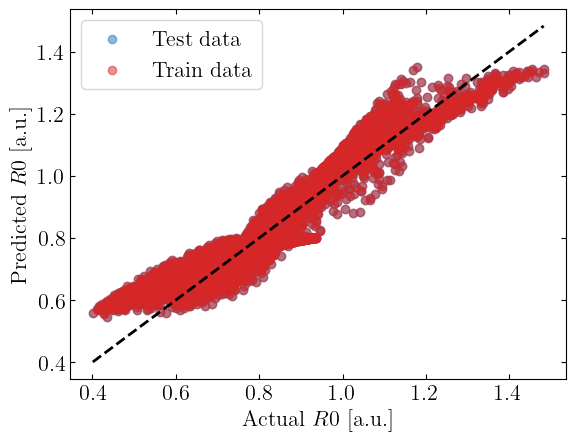

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp((soc**4 - exp(d*0.5450838*C))*0.32443264)**1.630419/0.7367165
Loss: 0.00244387
Best model complexity: 19


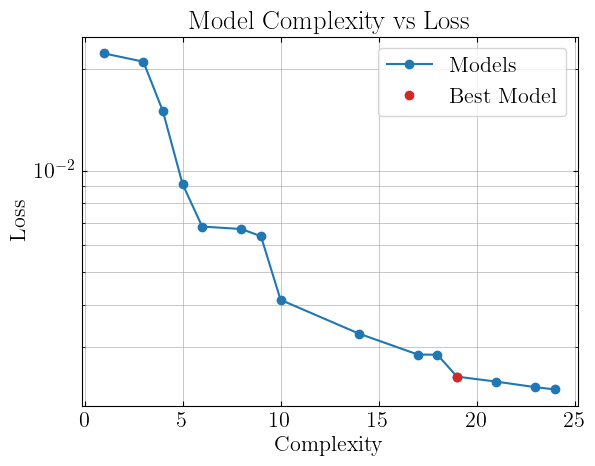

In [36]:
import_reload()
model_R0 = SR_lib.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R0')
df_model_R0 = model_R0.equations_
SR_lib.print_models(df_model_R0)
import_reload() 
SR_lib.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
SR_lib.print_best_model(model_R0)
SR_lib.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

Variable names for element R1: ['C', 'd', 'soc']
Running symbolic regression for element R1 with run_id R1_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=105.21213
Equation: 5.6768794

Model 1: Complexity=3, Loss=97.51518
Equation: C * 11.0890255

Model 2: Complexity=4, Loss=72.065735
Equation: cube(2.330351 - soc)

Model 3: Complexity=5, Loss=41.82237
Equation: square(cube(1.7242116 - soc))

Model 4: Complexity=6, Loss=37.643604
Equation: cube(3.1369307 - (soc / 0.23329175))

Model 5: Complexity=7, Loss=28.11501
Equation: cube(square(soc - 1.8961074)) * C

Model 6: Complexity=8, Loss=21.484257
Equation: cube(C + ((soc + -0.6217924) * -4.3079414))

Model 7: Complexity=10, Loss=21.118307
Equation: cube(C + (-3.1953912 - ((soc - 1.3838551) * 4.1885653)))

Model 8: Complexity=12, Loss=20.171175
Equation: cube(2.727515 + (C - cube(1.5493562 - (0.059758972 ^ soc))))

Model 9: Complexity=16, Loss=20.147617
Equation: cube((((2.722386 - cube(1.5852268 - (0.06763798 ^ soc))) + 0.02373206) + C) + 0.025206862)

Model 10: Complexity=17, Loss=17.554123
Equation: cube((C ^ soc) + (C + (1.698433 - cube(1.469742 - (0.0406421

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (C + (soc - 0.6217924)*(-4.3079414))**3
Loss: 21.484257
Best model complexity: 8


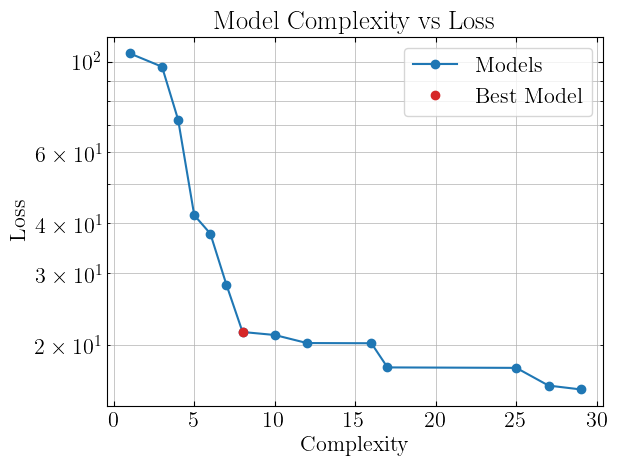

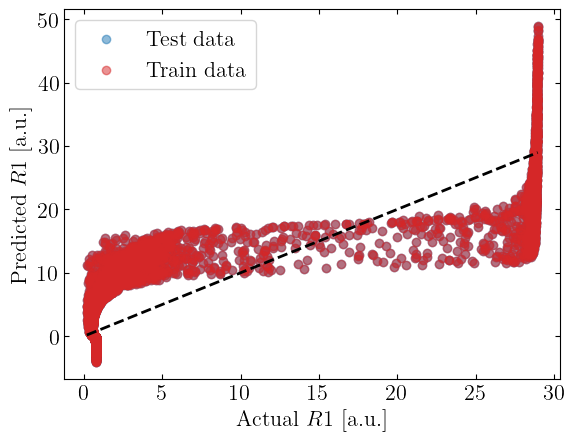

In [37]:
import_reload()
model_R1 = SR_lib.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'R1')
df_model_R1 = model_R1.equations_
SR_lib.print_models(df_model_R1)
SR_lib.print_best_model(model_R1)
SR_lib.pareto_plot(model_R1)
SR_lib.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

Variable names for element C1: ['C', 'd', 'soc']
Running symbolic regression for element C1 with run_id C1_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=14.735353
Equation: 9.446501

Model 1: Complexity=3, Loss=13.303794
Equation: soc + 8.871744

Model 2: Complexity=4, Loss=5.7029705
Equation: sqrt(soc) / 0.07131798

Model 3: Complexity=6, Loss=5.6165295
Equation: (sqrt(soc) / 0.07954446) - -1.1058413

Model 4: Complexity=7, Loss=4.870186
Equation: (sqrt(sqrt(soc)) / 0.05983884) - 3.8951235

Model 5: Complexity=8, Loss=4.732567
Equation: (sqrt(soc) / 0.053964086) - (soc * 5.5835013)

Model 6: Complexity=9, Loss=3.8296185
Equation: square(square(soc) - sqrt(sqrt(soc) / 0.0551845))

Model 7: Complexity=10, Loss=3.766009
Equation: square(square(square(soc)) - sqrt(sqrt(soc) / 0.060042042))

Model 8: Complexity=11, Loss=2.1862028
Equation: exp(exp(1.0079137 - cube(0.0333258 ^ soc))) - 3.5517983

Model 9: Complexity=13, Loss=1.3321494
Equation: exp(exp(1.0246856 - cube((C * 0.060977634) ^ soc))) - 4.5700336

Model 10: Complexity=14, Loss=1.2950096
Equation: exp(exp(1.022488 - square((square(C) * 0.022552831) ^ so

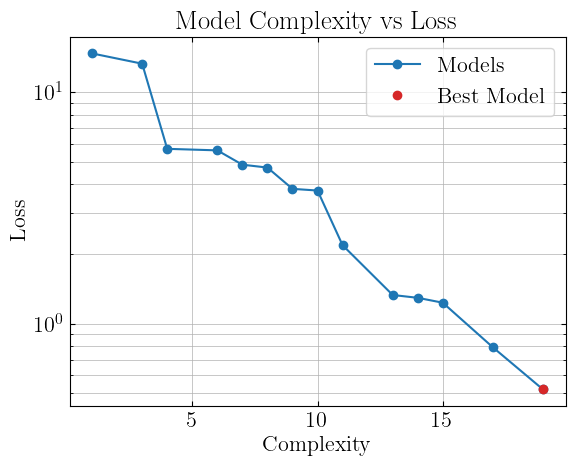

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: exp(exp(1.5961276 - (0.03613892**soc*C)**(9*soc)) - 1*2.3872447) - 1*1.2410084
Loss: 0.5205294
Best model complexity: 19


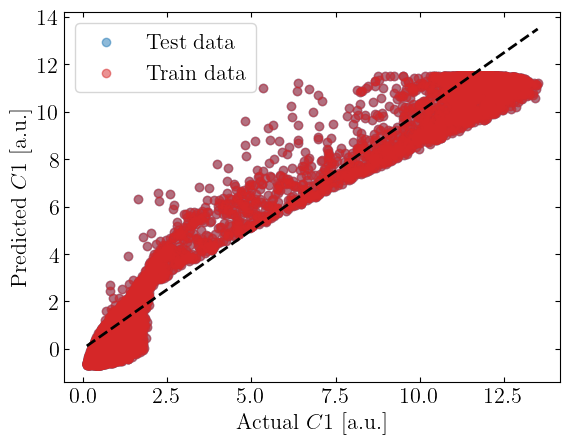

In [38]:
import_reload()
model_C1 = SR_lib.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'C1')
df_model_C1 = model_C1.equations_
SR_lib.print_models(df_model_C1)
SR_lib.pareto_plot(model_C1)
SR_lib.print_best_model(model_C1)
SR_lib.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

Variable names for element k: ['C', 'd', 'soc']
Running symbolic regression for element k with run_id k_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.14242901
Equation: 2.887136

Model 1: Complexity=3, Loss=0.015178867
Equation: d + 2.3871448

Model 2: Complexity=4, Loss=0.014986917
Equation: square(d) + 2.5555265

Model 3: Complexity=5, Loss=0.009404912
Equation: (d / 0.7888928) + 2.2557623

Model 4: Complexity=6, Loss=0.0079150135
Equation: (2.280624 ^ d) + 1.3357282

Model 5: Complexity=7, Loss=0.007854651
Equation: (d + (soc * -0.30914742)) + 2.5374196

Model 6: Complexity=8, Loss=0.0052051297
Equation: exp(d - (soc * 0.27022976)) + 1.38177

Model 7: Complexity=10, Loss=0.00015918232
Equation: exp(d + (-0.1774092 - (soc * 0.2284676))) + 1.6013101

Model 8: Complexity=14, Loss=0.0001591716
Equation: exp(((d + -0.17827512) - (soc * 0.10776071)) - (soc * 0.12085362)) + 1.6025147

Model 9: Complexity=16, Loss=3.2670974e-05
Equation: ((exp((d + 0.22121185) - (soc * 0.23434706)) ^ 0.35988736) ^ 2.1682367) + 1.2422497

Model 10: Complexity=18, Loss=3.250101e-05
Equation: ((exp(d + (0.22192131 - (soc * 0.23

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (exp(d - 0.23434706*soc + 0.22121185)**0.35988736)**2.1682367 + 1.2422497
Loss: 3.2670974e-05
Best model complexity: 16


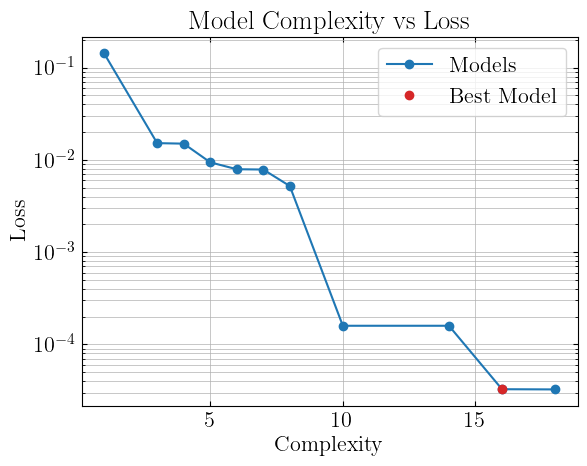

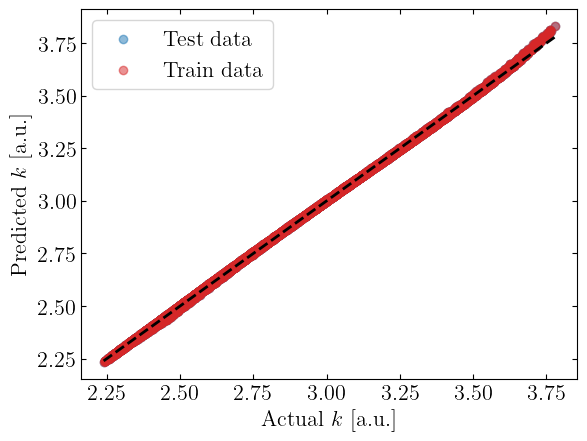

In [39]:
import_reload()
model_k = SR_lib.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION, elem = 'k')
df_model_k = model_k.equations_
SR_lib.print_models(df_model_k)
SR_lib.print_best_model(model_k)
SR_lib.pareto_plot(model_k)
SR_lib.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(i,d,\mathrm{SOC},s)$

Variable names for element s: ['C', 'd', 'soc', 's']
Running symbolic regression for element s with run_id s_test1...
Settings: iterations=15, populations=30, selection=best


/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:1046: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=1.0207422
Equation: 0.87002766

Model 1: Complexity=2, Loss=0.7823736
Equation: exp(C)

Model 2: Complexity=3, Loss=0.38232425
Equation: C * 3.0144453

Model 3: Complexity=4, Loss=0.36027333
Equation: exp(C) - d

Model 4: Complexity=5, Loss=0.1774261
Equation: square(exp(C - d))

Model 5: Complexity=6, Loss=0.06653872
Equation: C * exp(1.553489 - d)

Model 6: Complexity=7, Loss=0.045897104
Equation: C * square(exp(0.79446024) - d)

Model 7: Complexity=8, Loss=0.041858524
Equation: (s + square(d + -2.0789871)) * C

Model 8: Complexity=9, Loss=0.010013289
Equation: square(exp(0.7873062 - (d * d))) * C

Model 9: Complexity=10, Loss=0.0070047006
Equation: C * square((d * (-0.62188655 - d)) + 2.2420566)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: C*(4.82886958548246*exp(-2*d**2))
Loss: 0.010013289
Best model complexity: 9


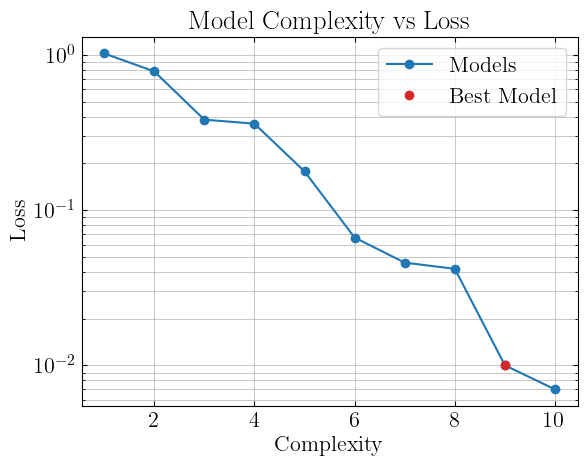

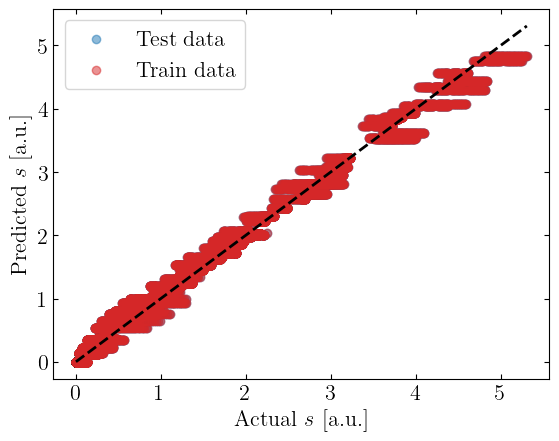

In [40]:
import_reload()
model_s = SR_lib.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION, elem = 's')
df_model_s = model_s.equations_
SR_lib.print_models(df_model_s)
SR_lib.print_best_model(model_s, s = True)
SR_lib.pareto_plot(model_s)
SR_lib.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [41]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    'sdot':  model_s
}

In [42]:
# def plot_soc(models, df_samples):
#     C_fixed = df_samples['C'].iloc
#     u_per_fixed = traj['u_per']
#     soc = traj['soc'].values

#     f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

#     for var in VARIABLES:
#         model = models[var]
#         if var == 's':
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
#             Y_true = traj['sdot']
#         else:
#             X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
#             Y_true = traj[var]
#         Y_plot = model.predict(X_plot) * REF_VALUES[var]
#         ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
#         ax[VARIABLES.index(var)].set_xlabel('SOC')
#         ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
#         ax[VARIABLES.index(var)].legend()
#         ax[VARIABLES.index(var)].invert_xaxis()
#     plt.tight_layout()



# traj = get_traj(trajectory_id = 1, test = True)
# plot_soc(MODEL_DICT, traj)

In [43]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [44]:
if SAVE:
    SR_lib.save_expressions(df_model_R0, f'R0_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_s, f's_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_s.get_best(), f's_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_k,  f'k_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_R1, f'R1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(df_model_C1, f'C1_{RUN_ID}', run_id = RUN_ID)
    SR_lib.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}', run_id = RUN_ID)